In [1]:
import pandas as pd
from pathlib import Path

class SimpleSCDLoader:
    def __init__(self, data_root: str):
        self.data_root = Path(data_root)
        self.csv_file = self.data_root / "scd_patientdata.csv"
        self.images_folder = self.data_root / "SCD_IMAGES"
        self.contours_folder = self.data_root / "scd_manualcontours" / "SCD_ManualContours"
        
        # Load CSV mapping
        self.df = pd.read_csv(self.csv_file)
        
    def create_image_contour_dataframe(self) -> pd.DataFrame:
        """Create a DataFrame with image_path, contour_path, contour_type columns"""
        rows = []
        
        for _, row in self.df.iterrows():
            scd_id = row['PatientID']
            original_id = row['OriginalID']
            
            # Get DICOM files
            patient_folder = self.images_folder / scd_id
            if not patient_folder.exists():
                continue
            dcm_files = list(patient_folder.glob("CINESAX*/*.dcm"))
            
            # Get contour folder (with zero-padding fix)
            contour_folder_parts = original_id.split("-")
            if len(contour_folder_parts[-1]) < 2:
                contour_folder_parts[-1] = contour_folder_parts[-1].zfill(2)
            contour_folder = self.contours_folder / "-".join(contour_folder_parts)
            
            if not contour_folder.exists():
                continue
                
            # Get contour files and create association
            contour_files = list(contour_folder.rglob("*.txt"))
            contour_association = {}
            
            for contour_file in contour_files:
                parts = contour_file.stem.split("-")
                image_name = parts[2]
                contour_type = "-".join(parts[3:])
                
                if image_name not in contour_association:
                    contour_association[image_name] = []
                    
                contour_association[image_name].append({
                    'contour_path': str(contour_file),
                    'contour_type': contour_type
                })
            
            # Match DICOM files with contours
            for dcm_file in dcm_files:
                dcm_stem = dcm_file.stem.split("-")[2]

                if dcm_stem in contour_association:
                    for contour_info in contour_association[dcm_stem]:
                        if contour_info['contour_type'].startswith(('icontour', 'ocontour')):
                            # Add to rows if contour type is relevant
                            rows.append({
                                'image_path': str(dcm_file),
                                'contour_path': contour_info['contour_path'],
                                'contour_type': contour_info['contour_type']
                            })

        return pd.DataFrame(rows)

loader = SimpleSCDLoader("../MRI/Sunnybrook")
df = loader.create_image_contour_dataframe()
df.head()

,image_path,contour_path,contour_type
0,../MRI/Sunnybrook/SCD_IMAGES/SCD0000101/CINESA...,../MRI/Sunnybrook/scd_manualcontours/SCD_Manua...,icontour-manual
1,../MRI/Sunnybrook/SCD_IMAGES/SCD0000101/CINESA...,../MRI/Sunnybrook/scd_manualcontours/SCD_Manua...,icontour-manual
2,../MRI/Sunnybrook/SCD_IMAGES/SCD0000101/CINESA...,../MRI/Sunnybrook/scd_manualcontours/SCD_Manua...,ocontour-manual
3,../MRI/Sunnybrook/SCD_IMAGES/SCD0000101/CINESA...,../MRI/Sunnybrook/scd_manualcontours/SCD_Manua...,icontour-manual
4,../MRI/Sunnybrook/SCD_IMAGES/SCD0000101/CINESA...,../MRI/Sunnybrook/scd_manualcontours/SCD_Manua...,ocontour-manual


In [2]:
df["image_path"][0]

'../MRI/Sunnybrook/SCD_IMAGES/SCD0000101/CINESAX_300/IM-0003-0108.dcm'

In [3]:
import json
import os

CONFIG = {
    "database_path": "../MRI/Sunnybrook",
    "output_path": "../Dataset/Sunnybrook/Landmarks_2_10",
    "scale_factor": 0.20, # 10% of the original average contour size
    "resolutions": ["full", "half"], # Names are only for reference
    # "resolutions": [1, 1/2, 1/4], # Actual scale factors
    "image_types": [""],  
    "organs": ["1", "2"], # ID in the mask
    "organ_names": ["LV endo", "LV epi"], # Name ID
    "inputsize": 256,
    "flip_h": True,
    "flip_v": True,
    "rotate": True,
    "transpose": True
}

os.makedirs(CONFIG["output_path"], exist_ok=True)
with open(os.path.join(CONFIG["output_path"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=4)

In [6]:
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

def organize_dataset(config):
    """
    Organizes the dataset into images and masks folders and creates a file list.
    
    Args:
    config (dict): Configuration dictionary containing paths and other settings.
    
    Returns:
    tuple: (image_list_path, mask_list_path)
    """
    image_dir = Path(config['output_path']) / 'images'
    landmarks_dir = Path(config['output_path']) / 'landmarks'
    masks_dir = Path(config['output_path']) / 'masks'  
    
    image_dir.mkdir(parents=True, exist_ok=True)
    landmarks_dir.mkdir(parents=True, exist_ok=True)
    masks_dir.mkdir(parents=True, exist_ok=True)

    image_list = []
    
    df = SimpleSCDLoader(config['database_path']).create_image_contour_dataframe()
    
    # This part will need to be adapted for each specific dataset
    for image_path in df['image_path'].unique():
        # Get all contours for this image
        image_contours = df[df['image_path'] == image_path]
        
        image_path = Path(image_path)
        
        dicom_data = pydicom.dcmread(image_path)
        image = dicom_data.pixel_array.astype(np.float32)
        # min-max normalization
        image = (image - np.min(image)) / (np.max(image) - np.min(image))
        image = (image * 255).astype(np.uint8)
        
        
        landmarks = {}
        
        for _, contour_row in image_contours.iterrows():
            contour_path = contour_row['contour_path']
            contour_type = contour_row['contour_type']            
        
            contour_points = np.loadtxt(contour_path, delimiter=' ') 
            
            # store them as integer coordinates
            contour_points = contour_points.astype(np.int32).tolist()
            
            # draw them and get them as a mask
            #mask = np.zeros_like(image, dtype=np.uint8)
            #cv2.drawContours(mask, [contour_points], -1, 1, thickness=cv2.FILLED)
            #contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            #largest_contour = max(contours, key=cv2.contourArea)
            #contour_points = largest_contour.reshape(-1, 2).tolist()
            
            if "icontour" in contour_type:
                contour_type = "1" # LV endocardium
            elif "ocontour" in contour_type:
                contour_type = "2" # LV epicardium
            else:
                continue            
            
            landmarks[contour_type] = contour_points
        
        # generate a mask by filling the contours
        mask = np.zeros_like(image, dtype=np.uint8)
        # first fill epi, then endo to handle holes
        if "2" in landmarks:
            cv2.drawContours(mask, [np.array(landmarks["2"])], -1, 2, thickness=cv2.FILLED)
        if "1" in landmarks:
            cv2.drawContours(mask, [np.array(landmarks["1"])], -1, 1, thickness=cv2.FILLED)
        
        image_path = str(image_path)
        
        image_id = image_path.split('/')[4] + "_" + image_path.split('/')[6].split('.')[0] 
        image_id = image_id.replace(" ", "_").replace("-", "_")
    
        image_path = f"{image_id}.png"
        
        cv2.imwrite(str(image_dir / image_path), image)
        
        landmark_path = landmarks_dir / f"{image_id}.json"
        
        with open(landmark_path, 'w') as f:
            json.dump(landmarks, f)
            
        cv2.imwrite(str(masks_dir / f"{image_id}.png"), mask)
        
        image_list.append(str(image_path))
        
        print(f"Processed image: {image_path}, with landmarks: {landmark_path}")
    
    # Write file lists
    image_list_path = Path(config['output_path']) / 'image_list.txt'
    
    with open(image_list_path, 'w') as f:
        f.write('\n'.join(image_list))
    
    return

In [7]:
# Step 1: Organize dataset
organize_dataset(CONFIG)

Processed image: SCD0000101_IM_0003_0108.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0108.json
Processed image: SCD0000101_IM_0003_0079.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0079.json
Processed image: SCD0000101_IM_0003_0068.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0068.json
Processed image: SCD0000101_IM_0003_0099.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0099.json
Processed image: SCD0000101_IM_0003_0179.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0179.json
Processed image: SCD0000101_IM_0003_0159.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0159.json
Processed image: SCD0000101_IM_0003_0088.png, with landmarks: ../Dataset/Sunnybrook/Landmarks_2_10/landmarks/SCD0000101_IM_0003_0088.json
Processed image: SCD0000101_IM_000

In [7]:
from utils.image_processing import get_contour_lengths

# Step 3: Get contour lengths
contour_lengths = get_contour_lengths(CONFIG, os.path.join(CONFIG["output_path"], "landmarks"))

In [8]:
contour_lengths


{'1': [192,
  179,
  211,
  264,
  200,
  353,
  228,
  263,
  129,
  218,
  156,
  210,
  134,
  337,
  73,
  128,
  71,
  232,
  137,
  229,
  153,
  229,
  301,
  310,
  205,
  144,
  109,
  153,
  233,
  205,
  193,
  198,
  109,
  270,
  185,
  116,
  281,
  231,
  169,
  309,
  266,
  269,
  288,
  174,
  142,
  116,
  232,
  73,
  357,
  146,
  244,
  131,
  236,
  127,
  219,
  127,
  139,
  64,
  108,
  152,
  263,
  313,
  211,
  236,
  112,
  145,
  114,
  98,
  230,
  280,
  149,
  187,
  67,
  181,
  133,
  242,
  125,
  178,
  116,
  57,
  298,
  355,
  132,
  250,
  285,
  229,
  190,
  138,
  211,
  77,
  225,
  82,
  113,
  234,
  126,
  274,
  143,
  292,
  266,
  186,
  175,
  227,
  134,
  228,
  157,
  266,
  208,
  264,
  132,
  74,
  96,
  229,
  221,
  206,
  57,
  227,
  279,
  114,
  214,
  203,
  186,
  145,
  312,
  285,
  124,
  238,
  104,
  236,
  229,
  162,
  146,
  128,
  118,
  281,
  116,
  209,
  245,
  160,
  372,
  17,
  143,
  217,
  198,
  181,


Contour lengths:
Organ 1: min=14, max=378, avg=198.69
Organ 2: min=66, max=455, avg=279.08


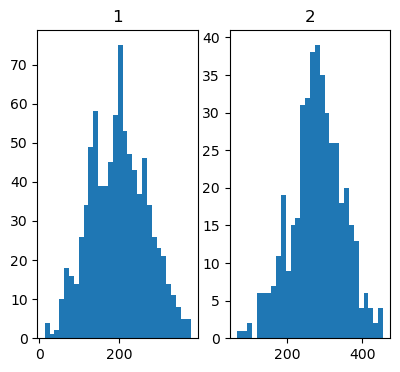

In [9]:
print("Contour lengths:")
for organ, lengths in contour_lengths.items():
    print(f"Organ {organ}: min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.2f}")

plt.figure(figsize=(12, 4))

for i, j in enumerate(contour_lengths.keys()):
    plt.subplot(1, 5, i+1)
    plt.hist(contour_lengths[j], bins=30)
    plt.title(j)

/tmp/ipykernel_234021/1104263073.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


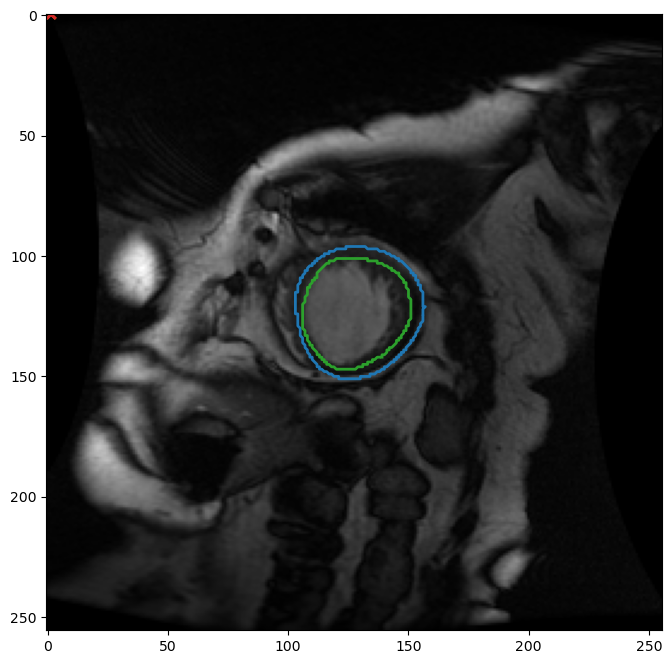

In [29]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[253]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / Path(image_list[253]).with_suffix('.json')

image = cv2.imread(str(image_path))
landmarks = json.load(open(landmarks_path))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)

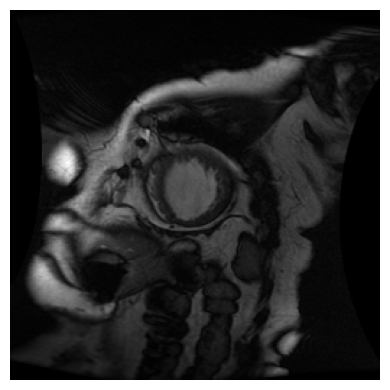

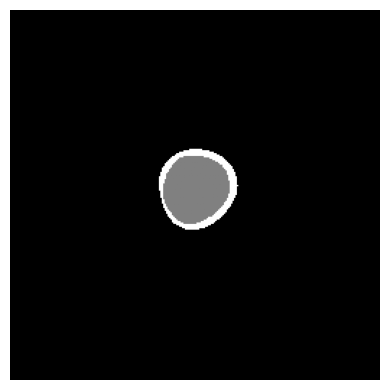

In [30]:
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
# remove white border
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.tight_layout()

mask = np.zeros(image.shape[:2], dtype=np.uint8)
for organ, contour in landmarks.items():
    contour = np.array(contour, dtype=np.int32)
    cv2.drawContours(mask, [contour], -1, int(organ), thickness=cv2.FILLED)

plt.figure(figsize=(4, 4))
plt.imshow(mask, cmap='gray')
plt.axis('off')
# remove white border
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.tight_layout()
plt.show()

In [12]:
# force reload the package, with one line
import importlib
import utils.matrix_ops
importlib.reload(utils.matrix_ops)

from utils.matrix_ops import generate_adjacency_matrices, save_matrices, create_sampling_matrix, generate_edge_info

adjacency_matrices, downsampling_matrices, upsampling_matrices = generate_adjacency_matrices(contour_lengths, CONFIG)

os.makedirs(f"{CONFIG['output_path']}/Independent", exist_ok=True)

for res in CONFIG["resolutions"]:
    save_matrices(adjacency_matrices[res], res, CONFIG)

for name, matrices in downsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Independent/downsampling_{name}.npy", block_matrix)

for name, matrices in upsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Independent/upsampling_{name}.npy", block_matrix)

generate_edge_info(CONFIG)

Organ 1 - Contour len mean: 198.69302325581396 - Atlas contour size: 40
Adjacency matrices sizes: [('full', 40), ('half', 20)]
Downsampling matrices sizes: [('to_half', 20)]
Organ 2 - Contour len mean: 279.0769230769231 - Atlas contour size: 56
Adjacency matrices sizes: [('full', 56), ('half', 28)]
Downsampling matrices sizes: [('to_half', 28)]


In [13]:
# Load the files .txt and separate them in training validation and test. Use a 80 - 10 - 10 split
import numpy as np
import random

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'

with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
patients = [Path(image).stem.split('_')[0] for image in image_list]
unique_patients = list(set(patients))

# split patients 80% train, 10% val, 10% test
random.seed(42)  # For reproducibility
random.shuffle(unique_patients)
n_patients = len(unique_patients)
train_patients = unique_patients[:int(0.8 * n_patients)]
val_patients = unique_patients[int(0.8 * n_patients):int(0.9 * n_patients)]
test_patients = unique_patients[int(0.9 * n_patients):]

train_images = [image for image in image_list if Path(image).stem.split('_')[0] in train_patients]
val_images = [image for image in image_list if Path(image).stem.split('_')[0] in val_patients]
test_images = [image for image in image_list if Path(image).stem.split('_')[0] in test_patients]

# save as txt

train_image_list_path = Path(CONFIG['output_path']) / 'train.txt'
val_image_list_path = Path(CONFIG['output_path']) / 'val.txt'
test_image_list_path = Path(CONFIG['output_path']) / 'test.txt'

with open(train_image_list_path, 'w') as f:
    f.write('\n'.join(train_images))
with open(val_image_list_path, 'w') as f:
    f.write('\n'.join(val_images))
with open(test_image_list_path, 'w') as f:
    f.write('\n'.join(test_images))